# GRIB: Interpolating from pressure to pressure levels

This notebook demonstrates how to interpolate GRIB fieldlist data on pressure levels to another set of pressure levels. Fieldlist support requires the usage of earthkit-data.

In [1]:
import earthkit.data as ekd

import earthkit.meteo.vertical.fieldlist as vertical

## Getting the data

The input is GRIB data on pressure levels. We fetch the file and extract the temperature fields from it.

In [2]:
fl = ekd.from_source("url", "https://sites.ecmwf.int/repository/earthkit-meteo/test-data/tz_pl.grib1").to_fieldlist()
t_in = fl.sel({"parameter.variable": "t"})
t_in.ls()

tz_pl.grib1:   0%|          | 0.00/30.5k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,850,pressure,0,regular_ll
2,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,700,pressure,0,regular_ll
3,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,500,pressure,0,regular_ll
4,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,400,pressure,0,regular_ll
5,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,300,pressure,0,regular_ll
6,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,200,pressure,0,regular_ll
7,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,150,pressure,0,regular_ll
8,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,100,pressure,0,regular_ll


## Using interpolate_monotonic

In [3]:
# define the target coordinates
target_coord = [87000.0, 35000.0]  # Pa

t_res = vertical.interpolate_monotonic(
    t_in,  # data to interpolate
    target_coord=target_coord,
    interpolation="linear",
)

Alternatively, we can specify all the arguments explicitly. This requires extracting the vertical coordinate values from the input data.

In [4]:
# extract the coordinates of the input fields
import numpy as np

coord = np.array(t_in.get("vertical.level")) * 100.0  # Pa

# define the target coordinates
target_coord = [87000.0, 35000.0]  # Pa

# define the coordinate type
# (must be an earthkit-data "vertical.level_type")
coord_type = "pressure"

t_res = vertical.interpolate_monotonic(
    t_in,  # data to interpolate
    coord=coord,
    target_coord=target_coord,
    coord_type=coord_type,
    interpolation="linear",
)

In [5]:
# list the result
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,870.0,pressure,0,regular_ll
1,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,350.0,pressure,0,regular_ll


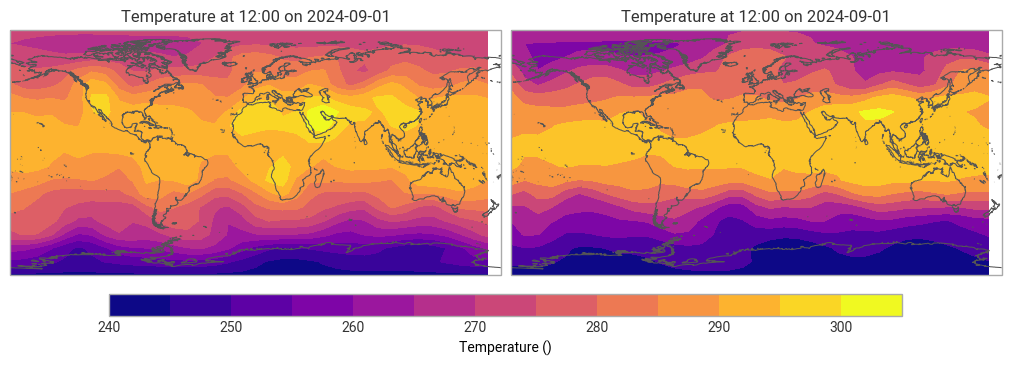

In [6]:
# generate plot the earthkit-plots
import earthkit.plots as ekp

ekp.quickplot(t_res)

## Writing to GRIB

In [7]:
# write to GRIB file
t_res.to_target("file", "_pl_to_pl.grib")

# read back and check saved GRIB data
ekd.from_source("file", "_pl_to_pl.grib").to_fieldlist().ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,870,pressure,0,regular_ll
1,t,2024-09-01 12:00:00,2024-09-01 12:00:00,0 days,350,pressure,0,regular_ll
